In [3]:
import pandas as pd 
df = pd.read_csv(r'D:\pytorch-1d2l\.venv\uniqlo.csv')

In [6]:
gs = df.groupby(['gender_group'])
display(gs)
gs['city']
display(gs.first()) # 取出每组第一条数据
display(gs.last())

,store_id,city,channel,age_group,wkd_ind,product,customer,revenue,order,quant,unit_cost
gender_group,,,,,,,,,,,
Female,658,深圳,线下,25-29,Weekday,当季新品,4,796.0,4,4,59
Male,70,深圳,线下,>=60,Weekday,T恤,2,178.0,2,2,49
Unkown,437,重庆,线下,Unkown,Weekend,T恤,1,99.0,1,1,49


,store_id,city,channel,age_group,wkd_ind,product,customer,revenue,order,quant,unit_cost
gender_group,,,,,,,,,,,
Female,758,杭州,线下,20-24,Weekday,袜子,1,26.0,1,1,9
Male,616,成都,线下,30-34,Weekday,当季新品,1,79.0,1,1,59
Unkown,335,上海,线下,Unkown,Weekend,袜子,1,79.0,1,1,9


In [11]:
gs = df.groupby(['gender_group', 'channel'])
display(gs.get_group(('Female', '线上')))

,store_id,city,channel,gender_group,age_group,wkd_ind,product,customer,revenue,order,quant,unit_cost
5,28,武汉,线上,Female,35-39,Weekend,T恤,1,97.00,1,1,49
25,375,广州,线上,Female,45-49,Weekday,当季新品,1,79.00,1,1,59
30,68,重庆,线上,Female,50-54,Weekend,短裤,2,106.00,2,3,19
49,207,上海,线上,Female,20-24,Weekend,T恤,1,99.00,1,1,49
50,32,武汉,线上,Female,50-54,Weekend,T恤,1,99.00,1,1,49
...,...,...,...,...,...,...,...,...,...,...,...,...
22239,52,武汉,线上,Female,50-54,Weekend,T恤,1,59.00,1,1,49
22243,207,上海,线上,Female,20-24,Weekday,当季新品,1,55.32,1,1,59
22244,52,武汉,线上,Female,40-44,Weekend,T恤,1,99.00,1,1,49
22269,182,广州,线上,Female,25-29,Weekday,当季新品,3,297.00,3,3,59


In [12]:
df.groupby(['city', 'channel']).agg({
      'revenue':'mean', 
      'unit_cost':'sum'
  })

revenue  unit_cost
city channel                       
上海   线上       187.603426      27980
     线下       154.623043      82359
北京   线下       226.098128      26163
南京   线下       246.301860      23140
广州   线上       153.470817      59631
     线下       133.368817      41091
成都   线下       136.160798      72041
杭州   线下       155.751252     173445
武汉   线上       180.977961      69225
     线下       153.258971      93858
深圳   线下       167.993511     201526
西安   线上       128.581239      10246
     线下       131.791838      64469
重庆   线上       144.672253       8028
     线下       147.764673      75055

In [14]:
data = {
    '性别': ['男', '女', '男', '女', '男', '女', '女', '男'],
    '购买': ['是', '否', '是', '是', '否', '否', '是', '否']
}

df = pd.DataFrame(data)
print(df)
# 创建交叉表
crosstab = pd.crosstab(df['性别'], df['购买'])
print(crosstab)

  性别 购买
0  男  是
1  女  否
2  男  是
3  女  是
4  男  否
5  女  否
6  女  是
7  男  否
购买  否  是
性别      
女   2  2
男   2  2


In [16]:
data = {
    '性别': ['男', '女', '男', '女', '男', '女'],
    '购买': ['是', '否', '是', '是', '否', '否'],
    '金额': [100, 150, 200, 130, 160, 120]
}
df = pd.DataFrame(data)
print(df)
# 创建透视表
pivot_table = pd.pivot_table(df, values='金额', index='性别', columns='购买', aggfunc='mean')
print(pivot_table)

  性别 购买   金额
0  男  是  100
1  女  否  150
2  男  是  200
3  女  是  130
4  男  否  160
5  女  否  120
购买      否      是
性别              
女   135.0  130.0
男   160.0  150.0


交叉表：
posi_neg   0   1
week            
0         18  35
1         27  25
2         14  38
3         24  28
4         21  31

占比：
posi_neg         0         1
week                        
0         0.339623  0.660377
1         0.519231  0.480769
2         0.269231  0.730769
3         0.461538  0.538462
4         0.403846  0.596154


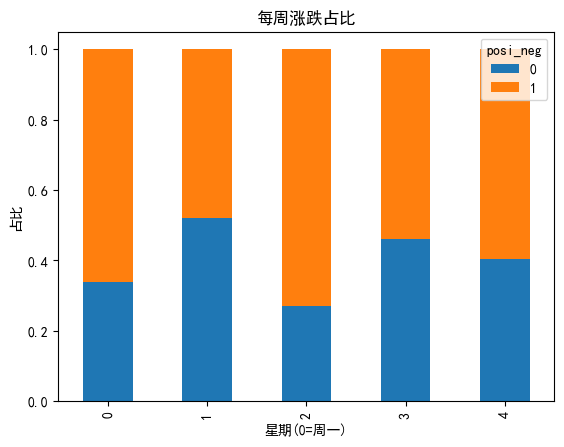


透视表（每周上涨占比）：
      posi_neg
week          
0     0.660377
1     0.480769
2     0.730769
3     0.538462
4     0.596154


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取（重要：index_col=0 把日期设为索引，否则pd.to_datetime(data.index)会失败）
data = pd.read_csv("stock_day.csv", index_col=0)

# 1、提取星期：0=周一，4=周五
date = pd.to_datetime(data.index).weekday
data['week'] = date

# 2、标记涨跌
data['posi_neg'] = np.where(data['p_change'] > 0, 1, 0)

# 交叉表
count = pd.crosstab(data['week'], data['posi_neg'])
print("交叉表：")
print(count)

# 求占比
total = count.sum(axis=1).astype(np.float32)
pro = count.div(total, axis=0)
print("\n占比：")
print(pro)

# 堆叠柱状图
pro.plot(kind='bar', stacked=True, title="每周涨跌占比")
plt.xlabel("星期(0=周一)")
plt.ylabel("占比")
plt.show()

# 透视表（等价实现）
print("\n透视表（每周上涨占比）：")
print(data.pivot_table(values='posi_neg', index='week'))
